# Atelier Preparation de Donnees Images

Objectif : construire un jeu de donnees images propre et homogene pour un modele de classification de dechets (cardboard, glass, metal, paper, plastic, trash).

## Partie 1 - Exploration du dataset

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

RAW_DIR = Path("../data/raw")
CLEANED_DIR = Path("../data/cleaned")
REPORTS_DIR = Path("../reports")

CLASSES = sorted([d.name for d in RAW_DIR.iterdir() if d.is_dir()])
CLASSES

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [2]:
for classe in CLASSES:
    nb_fichiers = len(list((RAW_DIR / classe).iterdir()))
    print(f"{classe}: {nb_fichiers} fichiers")

cardboard: 169 fichiers
glass: 188 fichiers
metal: 149 fichiers
paper: 252 fichiers
plastic: 224 fichiers
trash: 50 fichiers


In [3]:
def get_format_mode_dimensions(img):
    """Retourne (format, mode, largeur, hauteur) a partir d'une image PIL deja ouverte."""
    largeur, hauteur = img.size
    return img.format, img.mode, largeur, hauteur

In [4]:
def get_pixel_std(img):
    """Retourne l'ecart-type des valeurs de pixels d'une image PIL deja ouverte."""
    array = np.array(img)
    return float(array.std())

In [5]:
MODE_TO_CHANNELS = {
    "1": 1, "L": 1, "P": 1,
    "LA": 2,
    "RGB": 3,
    "RGBA": 4, "CMYK": 4,
}

def get_nb_channels(mode):
    """Deduit le nombre de canaux a partir du mode PIL de l'image."""
    return MODE_TO_CHANNELS.get(mode, len(mode))

def get_file_size(chemin):
    """Retourne la taille du fichier en octets."""
    return os.path.getsize(chemin)

In [6]:
def extraire_metadonnees(chemin, classe):
    """Ouvre une image et retourne un dictionnaire avec ses metadonnees.

    Si le fichier est corrompu ou illisible, les champs image sont a None
    et corrompue vaut True (pris en charge en Partie 2).
    """
    ligne = {
        "nom": chemin.name,
        "classe": classe,
        "format": None,
        "mode": None,
        "largeur": None,
        "hauteur": None,
        "ecart_type_pixels": None,
        "nb_canaux": None,
        "taille_octets": get_file_size(chemin),
        "corrompue": False,
    }

    try:
        with Image.open(chemin) as img:
            img.load()
            format_img, mode, largeur, hauteur = get_format_mode_dimensions(img)
            ligne["format"] = format_img
            ligne["mode"] = mode
            ligne["largeur"] = largeur
            ligne["hauteur"] = hauteur
            ligne["ecart_type_pixels"] = get_pixel_std(img)
            ligne["nb_canaux"] = get_nb_channels(mode)
    except Exception:
        ligne["corrompue"] = True

    return ligne

# test sur une seule image
premiere_image = next((RAW_DIR / CLASSES[0]).iterdir())
extraire_metadonnees(premiere_image, CLASSES[0])

{'nom': 'cardboard1.jpg',
 'classe': 'cardboard',
 'format': 'JPEG',
 'mode': 'RGB',
 'largeur': 512,
 'hauteur': 384,
 'ecart_type_pixels': 40.58852860499886,
 'nb_canaux': 3,
 'taille_octets': 17333,
 'corrompue': False}

In [7]:
lignes = []
for classe in CLASSES:
    for chemin in (RAW_DIR / classe).iterdir():
        if chemin.is_file():
            lignes.append(extraire_metadonnees(chemin, classe))

df_exploration = pd.DataFrame(lignes)
df_exploration.shape

(1032, 10)

## Partie 2 - Detecter les images corrompues

In [8]:
def est_corrompue(chemin):
    """Retourne True si le fichier ne peut pas etre ouvert/decode comme image valide."""
    try:
        with Image.open(chemin) as img:
            img.verify()
        with Image.open(chemin) as img:
            img.load()
        return False
    except Exception:
        return True

In [9]:
df_exploration["corrompue"] = df_exploration.apply(
    lambda ligne: est_corrompue(RAW_DIR / ligne["classe"] / ligne["nom"]), axis=1
)
df_exploration["corrompue"].value_counts()

corrompue
False    1026
True        6
Name: count, dtype: int64

In [10]:
nb_images_corrompues = int(df_exploration["corrompue"].sum())
print(f"Nombre d'images corrompues : {nb_images_corrompues}")

images_corrompues = df_exploration[df_exploration["corrompue"]][["nom", "classe"]]
images_corrompues

Nombre d'images corrompues : 6


,nom,classe
147,cardboard83.jpg,cardboard
326,glass74.jpg,glass
446,metal48.jpg,metal
633,paper213.jpg,paper
791,plastic13.jpg,plastic
1004,trash3.jpg,trash


## Partie 3 - Detecter les images vides

In [11]:
def est_noire_ou_blanche(array, seuil=5):
    """Retourne True si l'image est quasi entierement noire ou quasi entierement blanche."""
    moyenne = array.mean()
    return moyenne <= seuil or moyenne >= (255 - seuil)

In [12]:
def est_faible_variation(array, seuil_ecart_type=5):
    """Retourne True si les pixels de l'image presentent tres peu de variation."""
    return array.std() <= seuil_ecart_type

def est_vide(chemin):
    """Retourne True si l'image est consideree comme vide (noire, blanche ou peu de variation)."""
    with Image.open(chemin) as img:
        array = np.array(img.convert("L"))
    return est_noire_ou_blanche(array) or est_faible_variation(array)

In [13]:
def verifier_vide_securise(ligne):
    """Applique est_vide en excluant les images deja marquees corrompues."""
    if ligne["corrompue"]:
        return False
    chemin = RAW_DIR / ligne["classe"] / ligne["nom"]
    return est_vide(chemin)

df_exploration["vide"] = df_exploration.apply(verifier_vide_securise, axis=1)
df_exploration["vide"].value_counts()

vide
False    1028
True        4
Name: count, dtype: int64

In [14]:
nb_images_vides = int(df_exploration["vide"].sum())
print(f"Nombre d'images quasi vides : {nb_images_vides}")

images_vides = df_exploration[df_exploration["vide"]][["nom", "classe", "ecart_type_pixels"]]
images_vides

Nombre d'images quasi vides : 4


,nom,classe,ecart_type_pixels
167,image-blanche-512x384.jpg,cardboard,1.572536
355,image-noire-512x384.png,glass,110.418239
357,image-blanche-512x384.jpg,metal,1.572536
358,image-noire-512x384.png,metal,110.418239


## Partie 4 - Detecter les differences de resolution

In [15]:
df_valides = df_exploration[~df_exploration["corrompue"]].copy()
df_valides["resolution"] = list(zip(df_valides["largeur"].astype(int), df_valides["hauteur"].astype(int)))

resolutions_comptees = df_valides["resolution"].value_counts()

resolution_min = df_valides.loc[(df_valides["largeur"] * df_valides["hauteur"]).idxmin(), "resolution"]
resolution_max = df_valides.loc[(df_valides["largeur"] * df_valides["hauteur"]).idxmax(), "resolution"]

print(f"Resolution minimale (aire) : {resolution_min}")
print(f"Resolution maximale (aire) : {resolution_max}")
print("\nResolutions les plus frequentes :")
resolutions_comptees.head(10)

Resolution minimale (aire) : (32, 32)
Resolution maximale (aire) : (512, 384)

Resolutions les plus frequentes :


resolution
(512, 384)    1013
(32, 32)         5
(48, 32)         4
(40, 40)         4
Name: count, dtype: int64

In [16]:
print(f"Nombre de resolutions distinctes : {resolutions_comptees.shape[0]}")

df_resolutions = resolutions_comptees.rename_axis("resolution").reset_index(name="nb_images")
df_resolutions

Nombre de resolutions distinctes : 4


,resolution,nb_images
0,"(512, 384)",1013
1,"(32, 32)",5
2,"(48, 32)",4
3,"(40, 40)",4


In [17]:
TAILLE_MIN = 64

images_trop_petites = df_valides[
    (df_valides["largeur"] < TAILLE_MIN) | (df_valides["hauteur"] < TAILLE_MIN)
][["nom", "classe", "largeur", "hauteur"]]

print(f"Nombre d'images trop petites (< {TAILLE_MIN}x{TAILLE_MIN}) : {len(images_trop_petites)}")
images_trop_petites

Nombre d'images trop petites (< 64x64) : 13


,nom,classe,largeur,hauteur
20,cardboard117.jpg,cardboard,48.0,32.0
77,cardboard22.jpg,cardboard,32.0,32.0
133,cardboard70.jpg,cardboard,40.0,40.0
171,glass100.jpg,glass,40.0,40.0
229,glass15.jpg,glass,48.0,32.0
268,glass21.jpg,glass,32.0,32.0
270,glass23.jpg,glass,32.0,32.0
383,metal121.jpg,metal,48.0,32.0
413,metal2.jpg,metal,32.0,32.0
421,metal26.jpg,metal,40.0,40.0


## Partie 5 - Detecter les differents canaux

In [18]:
nb_par_canaux = df_valides["nb_canaux"].value_counts().sort_index()
print("Nombre d'images par nombre de canaux :")
nb_par_canaux

Nombre d'images par nombre de canaux :


nb_canaux
1.0       2
3.0    1006
4.0      18
Name: count, dtype: int64

## Partie 6 - Detecter les doublons

In [19]:
import hashlib

def hash_contenu_image(chemin):
    """Retourne un hash md5 base sur les pixels decodes de l'image (independant du format de fichier)."""
    with Image.open(chemin) as img:
        array = np.array(img.convert("RGB"))
    return hashlib.md5(array.tobytes()).hexdigest()

In [20]:
df_valides["hash"] = df_valides.apply(
    lambda ligne: hash_contenu_image(RAW_DIR / ligne["classe"] / ligne["nom"]), axis=1
)
df_valides[["nom", "classe", "hash"]].head()

,nom,classe,hash
0,cardboard1.jpg,cardboard,1c1f5c16cbdfbbd585b55f7cbcbda2f9
1,cardboard10.jpg,cardboard,25ad16dbd0aee9167d80c1a73a933c4d
2,cardboard100.jpg,cardboard,f0afa17b84c7a1a1812123ac4d15b4a2
3,cardboard101.jpg,cardboard,9de43fd5d692c56d55392b518ce1ad50
4,cardboard102.jpg,cardboard,12e24c482c6f4c8f2521170db537347a


In [21]:
doublons_mask = df_valides.duplicated(subset="hash", keep=False)
df_doublons = df_valides[doublons_mask].sort_values("hash")[["nom", "classe", "hash"]]

nb_doublons = int(df_valides.duplicated(subset="hash", keep="first").sum())
print(f"Nombre d'images en double (hors premiere occurrence) : {nb_doublons}")
df_doublons

Nombre d'images en double (hors premiere occurrence) : 15


,nom,classe,hash
980,plasticx199.jpg,plastic,020356755d7631716228a952bf3c3ead
869,plastic199.jpg,plastic,020356755d7631716228a952bf3c3ead
258,glass176.jpg,glass,03b62f7033ed13e63138ebd048abc4ea
817,plastic152.jpg,plastic,03b62f7033ed13e63138ebd048abc4ea
732,paper77ty.jpg,paper,116e03527a54192f3693d884d259d23b
731,paper77.jpg,paper,116e03527a54192f3693d884d259d23b
387,metal125.jpg,metal,16e737d7e848620a6e96cc7e4f75dd37
388,metal125po.jpg,metal,16e737d7e848620a6e96cc7e4f75dd37
168,image-violet-512x384.gif,cardboard,22a0ea89c32ebdf57e195d9d0b8da9d6
356,image-violet-512x384.gif,glass,22a0ea89c32ebdf57e195d9d0b8da9d6


## Partie 7 - Detecter les images mal classees

Controle visuel : affichage d'un echantillon d'images par classe pour reperer les images placees dans le mauvais dossier.

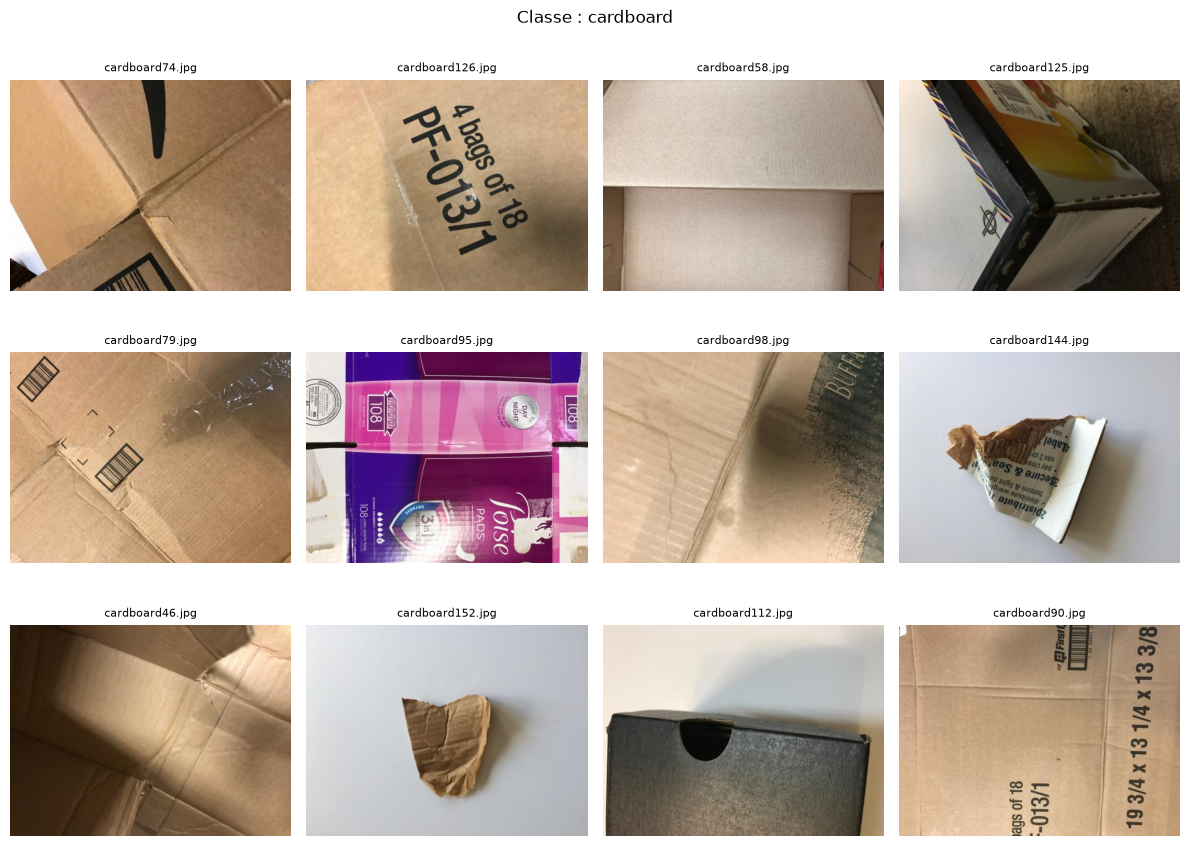

In [22]:
import matplotlib.pyplot as plt

def afficher_echantillon_classe(classe, n=12, seed=42):
    """Affiche un echantillon d'images d'une classe pour controle visuel."""
    sous_ensemble = df_valides[df_valides["classe"] == classe].sample(
        n=min(n, (df_valides["classe"] == classe).sum()), random_state=seed
    )
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    fig.suptitle(f"Classe : {classe}")
    for ax, (_, ligne) in zip(axes.flat, sous_ensemble.iterrows()):
        chemin = RAW_DIR / ligne["classe"] / ligne["nom"]
        with Image.open(chemin) as img:
            ax.imshow(img.convert("RGB"))
        ax.set_title(ligne["nom"], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

afficher_echantillon_classe(CLASSES[0])